### 모형
$$ y_1, \cdots, y_n \sim N(\mu, \sigma^2), \sigma^2 = \frac{1}{\tau^2} $$
$$ \mu \sim N(0, 10^2) $$
$$ \tau^2 \sim C^{+}(0,1)$$

In [2]:
import jax

In [3]:
n = 500
mu = 2
sigma = 1
y = mu + sigma * jax.random.normal(jax.random.PRNGKey(0), (n,))

In [4]:
import numpyro as npr
import numpyro.distributions as dist

d:\python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
def normal_model(y):
    # 모델 파라미터들을 정의합니다.
    mu = npr.sample('mu', dist.Normal(0, 10))
    sigma = npr.sample('sigma', dist.HalfNormal(1))
    
    # 관측 데이터에 대한 확률 분포를 정의합니다.
    with npr.plate('data', len(y)):
        npr.sample('obs', dist.Normal(mu, sigma), obs=y)

In [6]:
# 헤밀토니안 몬테카를로
from numpyro.infer import MCMC, NUTS

nuts_kernel = NUTS(normal_model)
mcmc = MCMC(nuts_kernel, num_samples=10000, num_warmup=5000, num_chains=2)
mcmc.run(jax.random.PRNGKey(1), y=y)

C:\Users\barkl\AppData\Local\Temp\ipykernel_14896\3722698989.py:5: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts_kernel, num_samples=10000, num_warmup=5000, num_chains=2)
sample: 100%|██████████| 15000/15000 [00:02<00:00, 5060.41it/s, 3 steps of size 8.33e-01. acc. prob=0.92]


In [7]:
# 사후표본 추출
ps = mcmc.get_samples(group_by_chain=True)

In [8]:
import matplotlib.pyplot as plt

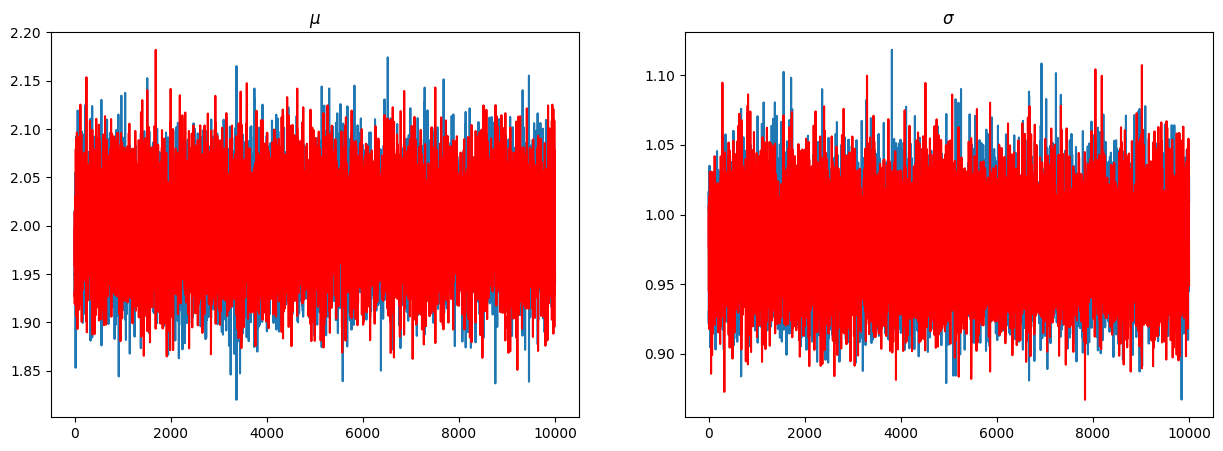

In [9]:
# 자취그림
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(ps['mu'][0]);
ax1.plot(ps['mu'][1],'r');
ax1.set_title(r'$\mu$');
ax2.plot(ps['sigma'][0]);
ax2.plot(ps['sigma'][1],'r');
ax2.set_title(r'$\sigma$');

plt.show()

In [10]:
# Gelman-Rubin 통계량
from numpyro.diagnostics import gelman_rubin

print(gelman_rubin(ps['mu']))
print(gelman_rubin(ps['sigma']))

0.99995047
1.000001


In [11]:
# 유효 표본수
from numpyro.diagnostics import effective_sample_size

print(effective_sample_size(ps['mu']))
print(effective_sample_size(ps['sigma']))

18154.45109507801
19624.878173628917


In [12]:
# 요약 통계량
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        mu      2.00      0.04      2.00      1.93      2.07  18154.45      1.00
     sigma      0.98      0.03      0.98      0.93      1.03  19624.88      1.00

Number of divergences: 0


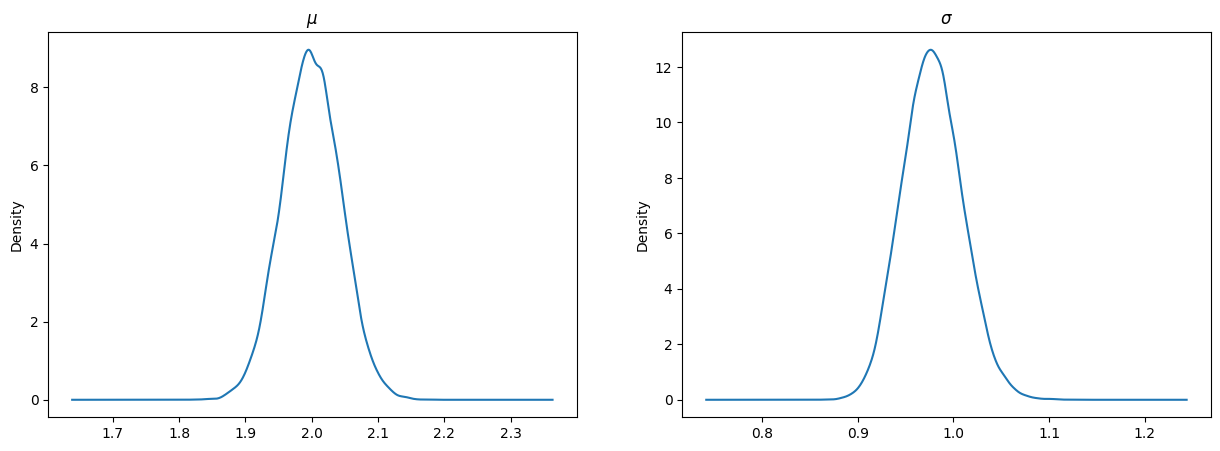

In [14]:
# 사후분포 그림
import pandas as pd

ps = mcmc.get_samples()
psd = pd.DataFrame(ps)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
psd['mu'].plot.kde()
plt.title(r'$\mu$')
plt.subplot(1, 2, 2)
psd['sigma'].plot.kde()
plt.title(r'$\sigma$')
plt.show()


In [ ]:
# 변분추론

# 변분분포 정의

from numpyro.infer.autoguide import AutoDiagonalNormal
from numpyro.infer.autoguide import AutoMultivariateNormal

guide = AutoDiagonalNormal(normal_model) # mean-field

In [ ]:
# 모형 최적화
from numpyro.infer import SVI, Trace_ELBO
from numpyro.optim import Adam

# 최적화를 위한 Adam 옵티마이저 설정
optimizer = Adam(step_size=0.001)

# SVI 객체 생성
svi = SVI(normal_model, guide, optimizer, loss=Trace_ELBO())

In [17]:
# SVI 실행
n_steps = 10000
svi_state = svi.init(jax.random.PRNGKey(0), y)

# 최적화 루프
elbo_values = []
for step in range(n_steps):
    svi_state, elbo = svi.update(svi_state, y)
    elbo_values.append(-elbo)
    if step % 1000 == 0:
        print('step {}: ELBO = {}'.format(step, elbo))

step 0: ELBO = 1191.0233154296875
step 1000: ELBO = 850.4874877929688
step 2000: ELBO = 707.1286010742188
step 3000: ELBO = 707.4817504882812
step 4000: ELBO = 706.3810424804688
step 5000: ELBO = 706.328369140625
step 6000: ELBO = 706.97412109375
step 7000: ELBO = 706.051513671875
step 8000: ELBO = 706.1412963867188
step 9000: ELBO = 706.0712890625


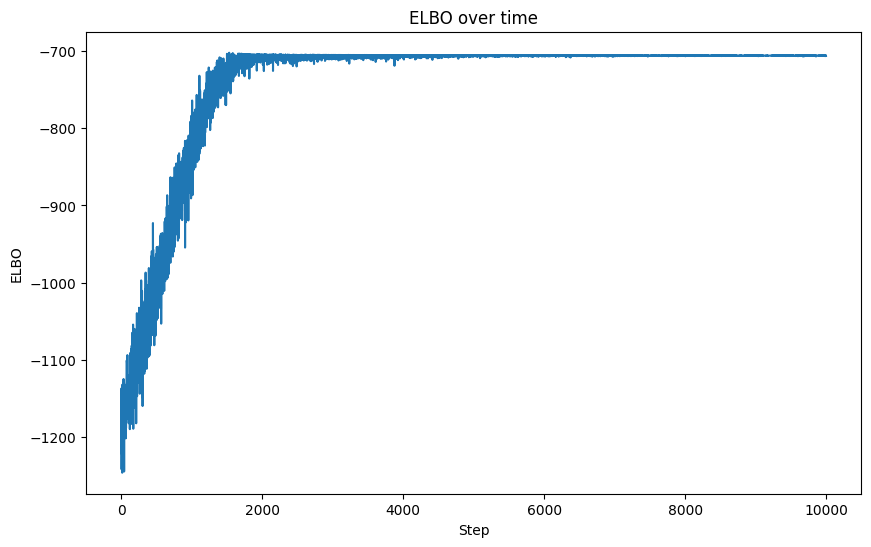

In [18]:
# 수렴성 판단
plt.figure(figsize=(10, 6))
plt.plot(elbo_values)
plt.title('ELBO over time')
plt.xlabel('Step')
plt.ylabel('ELBO')
plt.show()

In [19]:
# 추론
params = svi.get_params(svi_state)
print(params)

{'auto_loc': Array([ 2.0001173 , -0.03246249], dtype=float32), 'auto_scale': Array([0.04435917, 0.03235635], dtype=float32)}


### 추가 예제  

### 베이지안 회귀모형

### Model
$$ y \sim N(X\beta, \frac{1}{\tau}I_{n}) $$
where $y=(y_1,\cdots,y_N)^T$ and $X \in \mathbb{R}^{N\times p}$ is the design matrix.

### Priors
$$ \beta \sim N(0, \frac{1}{\alpha}I_p), \tau \sim Ga(a_{\tau}, b_{\tau}) $$

### Variational distribution
$$ q_\lambda(\theta) = N(\beta | \mu_{N,\beta}, \sigma^2_{N,\beta}) Ga(\tau | a_{N,\tau}, b_{N,\tau}), $$
where $\theta = (\beta, \tau)^{T}$ and $\lambda = (\mu_{N,\beta}, \sigma^2_{N,\beta}, a_{N,\tau}, b_{N,\tau})$

In [ ]:
# 데이터
import pandas as pd

dset = pd.read_csv('WaffleDivorce.csv', sep=';')
dset.head()

,Location,Loc,Population,MedianAgeMarriage,Marriage,Marriage SE,Divorce,Divorce SE,WaffleHouses,South,Slaves1860,Population1860,PropSlaves1860
0,Alabama,AL,4.78,25.3,20.2,1.27,12.7,0.79,128,1,435080,964201,0.45
1,Alaska,AK,0.71,25.2,26.0,2.93,12.5,2.05,0,0,0,0,0.00
2,Arizona,AZ,6.33,25.8,20.3,0.98,10.8,0.74,18,0,0,0,0.00
3,Arkansas,AR,2.92,24.3,26.4,1.70,13.5,1.22,41,1,111115,435450,0.26
4,California,CA,37.25,26.8,19.1,0.39,8.0,0.24,0,0,0,379994,0.00


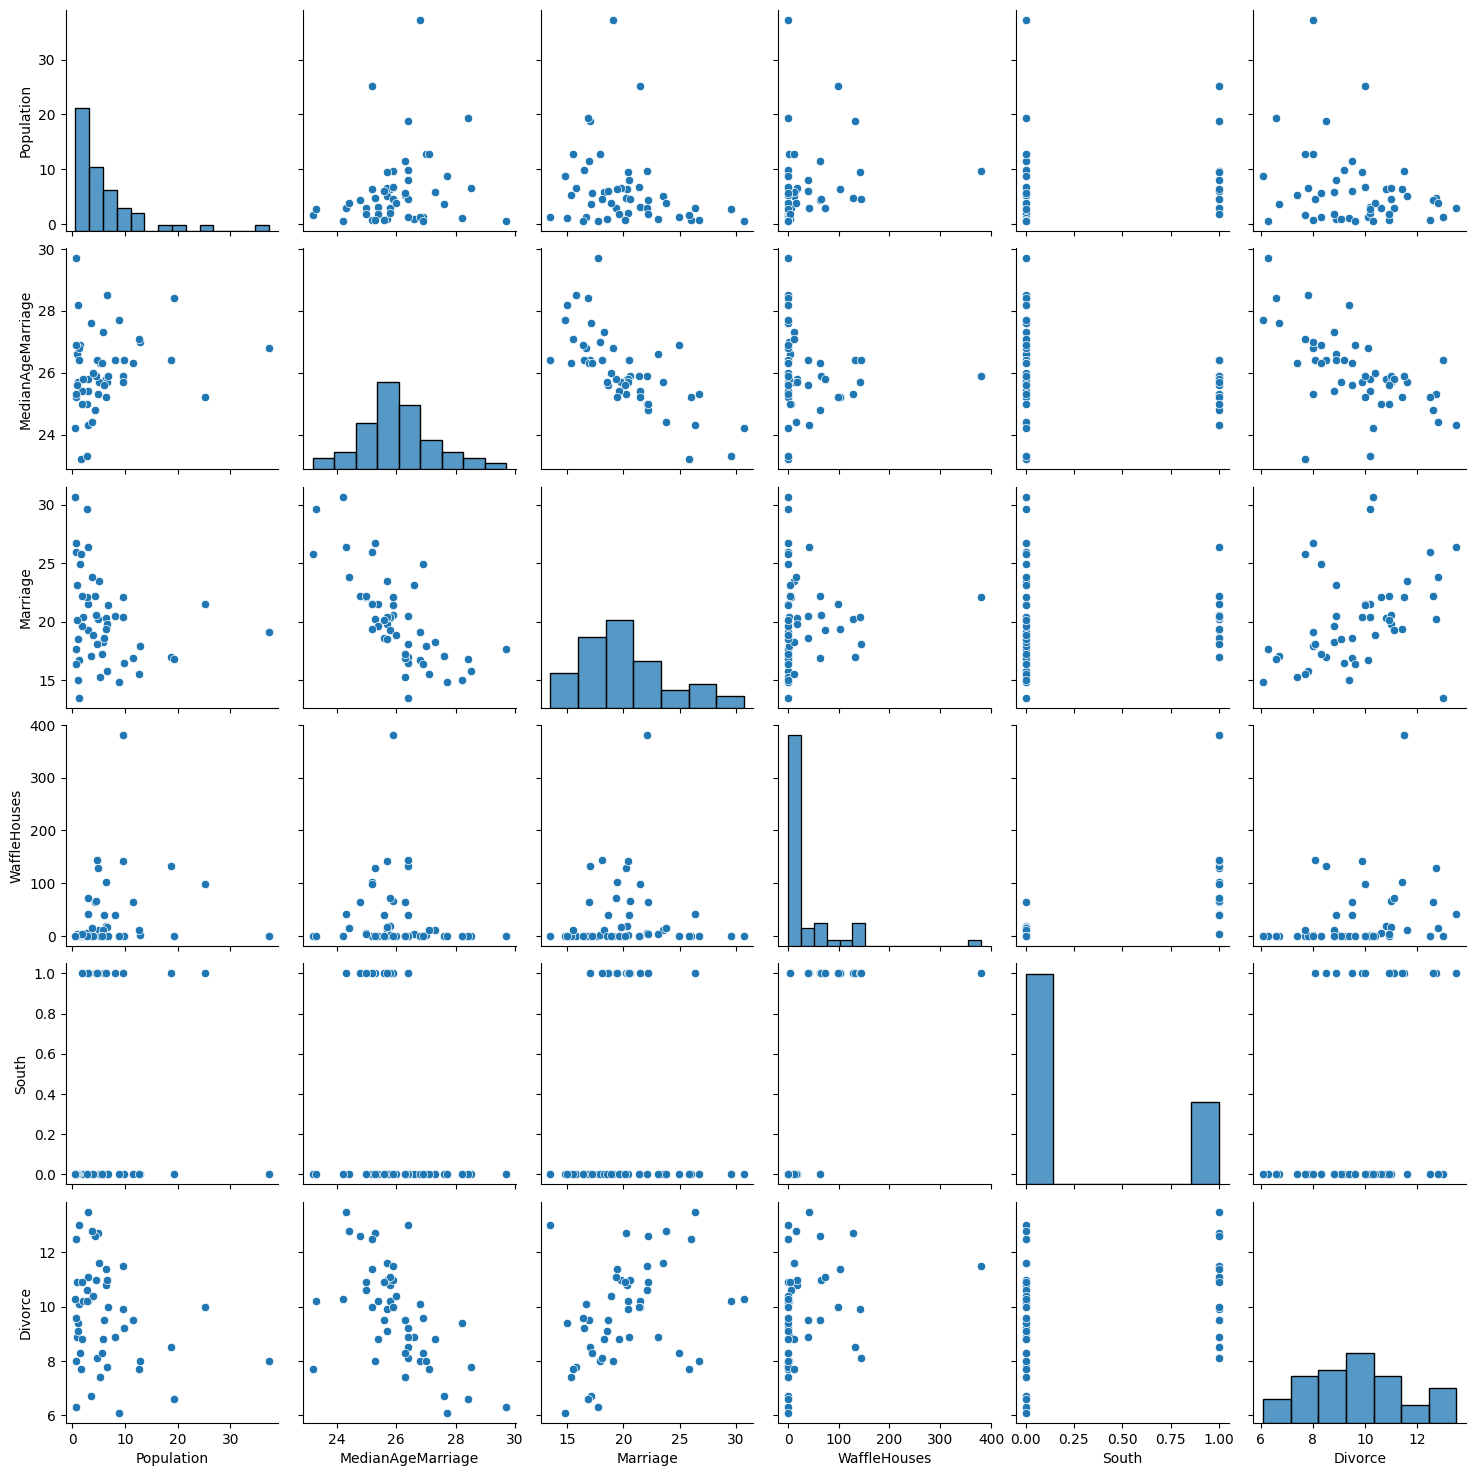

In [22]:
import seaborn as sns

vars = [
    "Population",
    "MedianAgeMarriage",
    "Marriage",
    "WaffleHouses",
    "South",
    "Divorce",
]
sns.pairplot(dset, x_vars=vars, y_vars=vars);

In [ ]:
# 데이터 표준화 (평균 0, 표준편차 1)
standardize = lambda x: (x - x.mean()) / x.std()

dset["AgeScaled"] = dset.MedianAgeMarriage.pipe(standardize)
dset["MarriageScaled"] = dset.Marriage.pipe(standardize)
dset["DivorceScaled"] = dset.Divorce.pipe(standardize)

In [ ]:
# 모형정의 - likelihood, prior
import jax
import numpyro
import numpyro.distributions as dist

def regmodel(marriage=None, divorce=None):
    # prior
    a = numpyro.sample("a", dist.Normal(0, 10)) # 절편
    bM = numpyro.sample("bM", dist.Normal(0, 10)) # 기울기
    M = bM * marriage 
    tausq = numpyro.sample("tausq", dist.Gamma(0.01, 0.01))
    sigma = jax.numpy.sqrt(1.0/tausq)
    mu = a + M

    # likelihood
    with numpyro.plate('data', len(divorce)):
        numpyro.sample("obs", dist.Normal(mu, sigma), obs=divorce)

In [29]:
# 변분분포 정의
def guide(marriage=None, divorce=None):
    # tau
    alpha_tau = numpyro.param("alpha_tau", 1.0, constraint=dist.constraints.positive)
    beta_tau = numpyro.param("beta_tau", 1.0, constraint=dist.constraints.positive)
    numpyro.sample("tausq", dist.Gamma(alpha_tau, beta_tau))

    # a
    loc_a = numpyro.param("loc_a", 0.0)
    scale_a = numpyro.param("scale_a", 1.0, constraint=dist.constraints.positive)
    numpyro.sample("a", dist.Normal(loc_a, scale_a))

    # bM
    loc_b = numpyro.param("loc_b", 0.0)
    scale_b = numpyro.param("scale_b", 1.0, constraint=dist.constraints.positive)
    numpyro.sample("bM", dist.Normal(loc_b, scale_b))

In [30]:
# 최적화
from numpyro.infer import SVI, Trace_ELBO
from numpyro.optim import Adam

# 최적화를 위한 Adam 옵티마이저 설정
optimizer = Adam(step_size=0.001)

# SVI 객체 생성
svi = SVI(regmodel, guide, optimizer, loss=Trace_ELBO())

# SVI 실행
n_steps = 10000
svi_state = svi.init(jax.random.PRNGKey(0), dset.MarriageScaled.values, divorce=dset.DivorceScaled.values)

# 최적화 루프
elbo_values = []
for step in range(n_steps):
    svi_state, elbo = svi.update(svi_state, dset.MarriageScaled.values, divorce=dset.DivorceScaled.values)
    elbo_values.append(-elbo)
    if step % 1000 == 0:
        print('step {}: ELBO = {}'.format(step, elbo))

step 0: ELBO = 83.14292907714844
step 1000: ELBO = 112.20189666748047
step 2000: ELBO = 94.10113525390625
step 3000: ELBO = 134.96812438964844
step 4000: ELBO = 82.73347473144531
step 5000: ELBO = 91.54209899902344
step 6000: ELBO = 79.43311309814453
step 7000: ELBO = 87.23365783691406
step 8000: ELBO = 80.47061157226562
step 9000: ELBO = 79.99974822998047


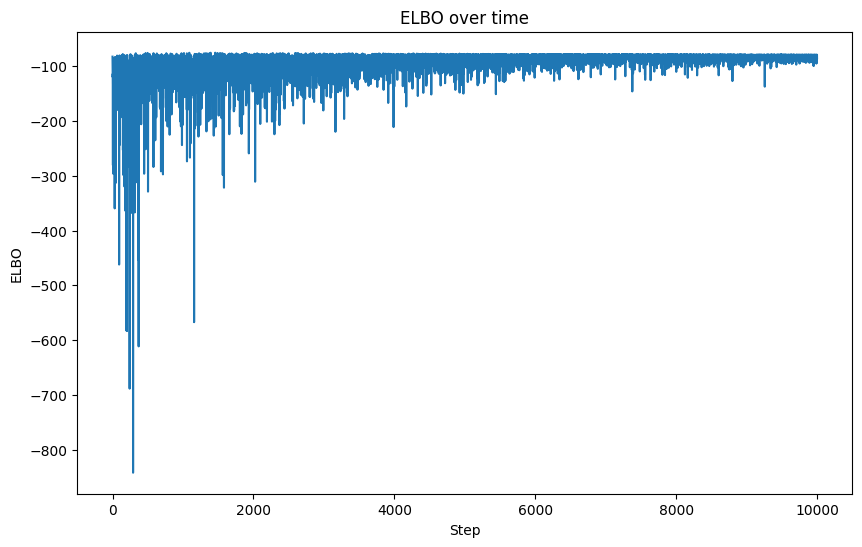

In [31]:
# 수렴성 판단
plt.figure(figsize=(10, 6))
plt.plot(elbo_values)
plt.title('ELBO over time')
plt.xlabel('Step')
plt.ylabel('ELBO')
plt.show()